##### I. Setup

In [ ]:
import os
from pyspark.sql import SparkSession, DataFrame
from google.colab import files
from pyspark.sql.functions import *
from pyspark.sql.types import TimestampType
from functools import reduce
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyspark.sql.window import Window
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [ ]:
!pip uninstall -y pyspark pyspark-connect dataproc-spark-connect

Found existing installation: pyspark 4.0.4
Uninstalling pyspark-4.0.4:
  Successfully uninstalled pyspark-4.0.4


In [ ]:
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless -qq
!pip install -q pyspark==3.5.1

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
!pip uninstall -y pyspark
!pip install -q pyspark==4.0.4

Found existing installation: pyspark 3.5.1
Uninstalling pyspark-3.5.1:
  Successfully uninstalled pyspark-3.5.1


In [ ]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [ ]:
!java -version

openjdk version "17.0.20" 2026-07-21
OpenJDK Runtime Environment (build 17.0.20+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.20+8-1-24.04-Ubuntu, mixed mode, sharing)


In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("DataCleaning")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
files= files.upload()

Saving OnlineRetail.csv to OnlineRetail (1).csv


In [ ]:
# create a data file within working directory to save csv files
from pathlib import Path
Path("data_files").mkdir(exist_ok=True)

In [ ]:
# create a plot file within working directory to save plot
from pathlib import Path
Path("/content/drive/MyDrive/Dinh Thi Thanh Hang- Portfolio/Data Viz").mkdir(exist_ok=True)

##### II. Load data

In [ ]:
df = spark.read.csv("OnlineRetail.csv", header=True, inferSchema=True)
df.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
only showing top 5 rows


In [ ]:
final_df = final_df.withColumn(
    "Revenue",
    F.col("Quantity") * F.col("UnitPrice")
)
total_revenue = final_df.agg(F.sum("Revenue")).collect()[0][0]
print(f'Total Revenue: {format_km(total_revenue)}')

Total Revenue: 8.74M


In [ ]:
total_orders = final_df.select("InvoiceNo").distinct().count()
print(f'Total Orders: {format_km(total_orders)}')

Total Orders: 18.40K


In [ ]:
order_df = final_df.groupBy("InvoiceNo").agg(
    F.sum("Revenue").alias("order_revenue")
)

AOV = order_df.agg(F.avg("order_revenue")).collect()[0][0]
print(f'Average Order Value: {format_km(AOV)}')

Average Order Value: 475


In [ ]:
order_df.agg(
    F.expr("percentile_approx(order_revenue, 0.5)").alias("median_AOV"),
    F.expr("percentile_approx(order_revenue, 0.9)").alias("p90_AOV"),
    F.expr("percentile_approx(order_revenue, 0.95)").alias("p95_AOV"),
    F.expr("percentile_approx(order_revenue, 0.99)").alias("p99_AOV")
).show()

+----------+-------+------------------+-------+
|median_AOV|p90_AOV|           p95_AOV|p99_AOV|
+----------+-------+------------------+-------+
|     301.6| 809.92|1209.8799999999999| 3733.0|
+----------+-------+------------------+-------+



In [ ]:
orders = order_df.select("order_revenue").toPandas()

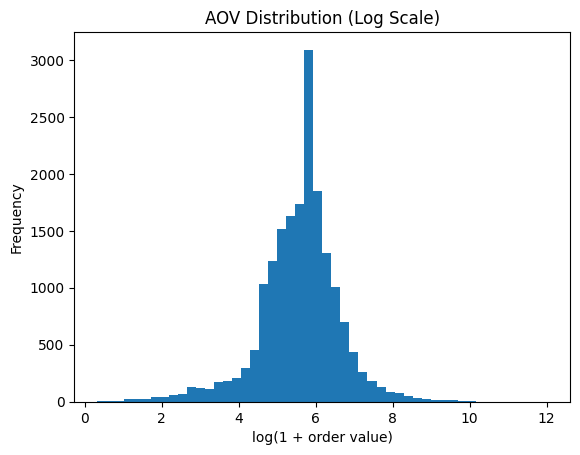

In [ ]:
import numpy as np

plt.figure()
plt.hist(np.log1p(orders["order_revenue"]), bins=50)
plt.title("AOV Distribution (Log Scale)")
plt.xlabel("log(1 + order value)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
basket_df = final_df.groupBy("InvoiceNo").agg(
    F.sum("Quantity").alias("items_per_order")
)

avg_basket_size = basket_df.agg(
    F.avg("items_per_order")
).collect()[0][0]

print(format_km(avg_basket_size))

279


In [ ]:
basket_df.agg(
    F.expr("percentile_approx(items_per_order, 0.5)").alias("median"),
    F.expr("percentile_approx(items_per_order, 0.9)").alias("p90"),
    F.expr("percentile_approx(items_per_order, 0.95)").alias("p95"),
    F.expr("percentile_approx(items_per_order, 0.99)").alias("p99")
).show()

+------+---+---+----+
|median|p90|p95| p99|
+------+---+---+----+
|   156|513|778|2256|
+------+---+---+----+



In [ ]:
basket = basket_df.select("items_per_order").toPandas()

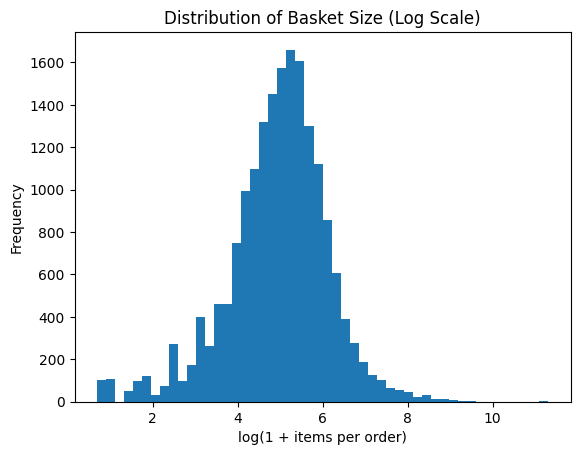

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.hist(np.log1p(basket["items_per_order"]), bins=50)
plt.title("Distribution of Basket Size (Log Scale)")
plt.xlabel("log(1 + items per order)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
customer_freq = final_df.groupBy("CustomerID").agg(
    F.countDistinct("InvoiceNo").alias("frequency"),
)

avg_order_frequency = customer_freq.agg(
    F.avg("frequency")
).collect()[0][0]
print(f'Average Order Frequency: {avg_order_frequency}')

Average Order Frequency: 4.2459621596677435


In [ ]:
freq= customer_freq.select('frequency').toPandas()

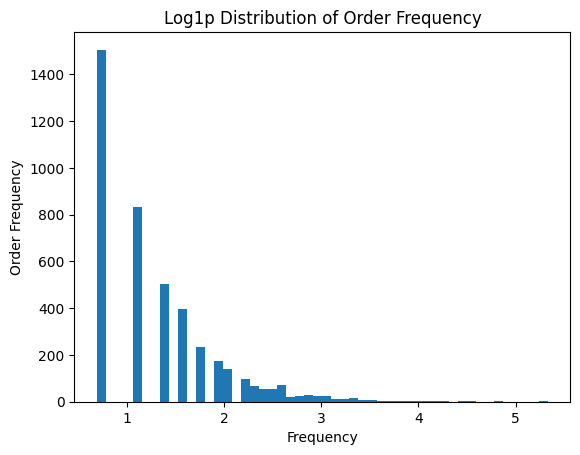

In [ ]:
plt.figure()
plt.hist(np.log1p(freq['frequency']), bins= 50)
plt.title("Log1p Distribution of Order Frequency")
plt.xlabel("Frequency")
plt.ylabel("Order Frequency")
plt.show()

In [ ]:
df_daily = final_df.select("CustomerID", F.to_date("InvoiceDate").alias("PurchaseDate")).distinct()

w = Window.partitionBy("CustomerID").orderBy("PurchaseDate")

df_gap = df_daily.withColumn(
    "prev_date",
    F.lag("PurchaseDate").over(w)
).withColumn(
    "time_gap_days",
    F.datediff("PurchaseDate", F.col("prev_date"))
).filter(F.col("time_gap_days").isNotNull())

In [ ]:
df_gap.agg(

    F.avg("time_gap_days").alias("mean_gap"),

    F.expr("percentile(time_gap_days, 0.5)").alias("median_gap"),

    F.expr("percentile(time_gap_days, 0.9)").alias("p90_gap"),

    F.expr("percentile(time_gap_days, 0.99)").alias("p99_gap")

).show()

+------------------+----------+-------+-------+
|          mean_gap|median_gap|p90_gap|p99_gap|
+------------------+----------+-------+-------+
|45.856529488010366|      28.0|  111.0|  260.0|
+------------------+----------+-------+-------+



In [ ]:
gap = df_gap.select("time_gap_days").toPandas()

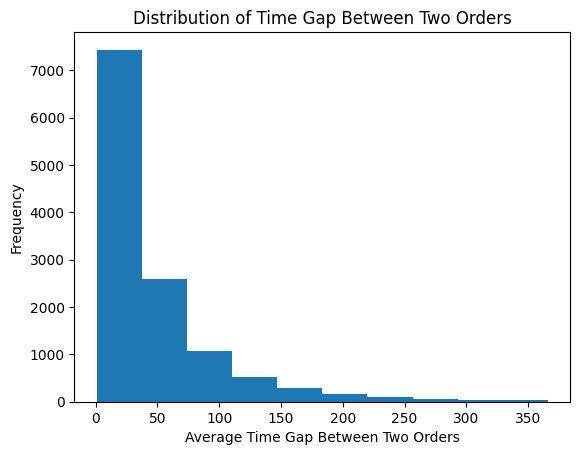

In [ ]:
plt.figure()
plt.hist(gap["time_gap_days"], bins= 10)
plt.title("Distribution of Time Gap Between Two Orders")
plt.xlabel("Average Time Gap Between Two Orders")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#  distribution of unit price
unit_price= final_df.select("UnitPrice").toPandas()

In [ ]:
final_df.agg(

    F.avg("UnitPrice").alias("mean_unitprice"),

    F.expr("percentile(UnitPrice, 0.5)").alias("median_unitprice"),

    F.expr("percentile(UnitPrice, 0.9)").alias("p90_unitprice"),

    F.expr("percentile(UnitPrice, 0.99)").alias("p99_unitprice")

).show()

+------------------+----------------+-------------+-------------+
|    mean_unitprice|median_unitprice|p90_unitprice|p99_unitprice|
+------------------+----------------+-------------+-------------+
|2.8743503258331247|            1.95|         6.25|        12.75|
+------------------+----------------+-------------+-------------+



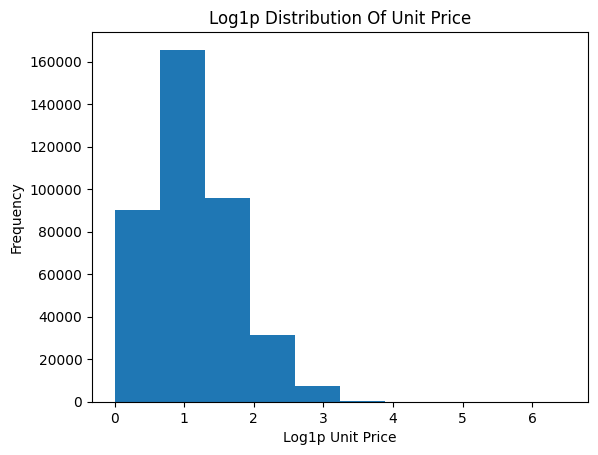

In [ ]:
plt.figure()
plt.hist(np.log1p(unit_price["UnitPrice"]), bins=10)
plt.xlabel("Log1p Unit Price")
plt.ylabel("Frequency")
plt.title("Log1p Distribution Of Unit Price")
plt.show()

### IX. Model Development

### Feature Engineering:


In [ ]:
final_df.show(5)

+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-----------+-----+----+----------+------------+----+-------------+-------------------+-------------------+---------------------+----------------+-------+-------------+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|       Country|Customer_Type|Recency|Frequency|Monetary|Churn|day_of_week|month|year|month_year|quarter_year|hour|week_of_month|is_christmas_season|is_valentine_season|is_mothers_day_season|is_easter_season|Revenue|price_segment|
+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-----------+-----+----+----------+------------+----+-------------+-------------------+-------------------+---------------------+----------------+-------+-------------+
|     12346|   541431|    23166|ME

In [ ]:
# ============================================================
# 0. IMPORTS
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel
from pyspark.ml.functions import vector_to_array

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator


# ============================================================
# 1. CONFIG
# ============================================================

LOOKBACK_DAYS = 180
PREDICTION_HORIZON = 30

LABEL_COL = "inactive_next_30d"


# ============================================================
# 2. START FROM final_df
#    final_df = ORDER LINE ITEM LEVEL
# ============================================================

# Remove old leakage-prone columns.
drop_cols = [
    "Churn",
    "Recency",
    "Frequency",
    "Monetary"
]

existing_drop_cols = [
    c for c in drop_cols
    if c in final_df.columns
]

line_df = (
    final_df
    .drop(*existing_drop_cols)

    # Identified customers only
    .filter(F.col("CustomerID").isNotNull())

    # Positive purchase only
    .filter(F.col("Quantity") > 0)
    .filter(F.col("UnitPrice") > 0)

    # Date
    .withColumn(
        "transaction_date",
        F.to_date("InvoiceDate")
    )
)

if "Customer_Type" in line_df.columns:
    line_df = line_df.filter(
        F.col("Customer_Type") == "Identified"
    )


# ============================================================
# 3. CREATE REVENUE IF NEEDED
# ============================================================

if "Revenue" not in line_df.columns:

    line_df = (
        line_df
        .withColumn(
            "Revenue",
            F.col("Quantity")
            * F.col("UnitPrice")
        )
    )


# Keep only columns needed downstream.
# Important for Spark performance.

line_df = line_df.select(
    "CustomerID",
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "UnitPrice",
    "Revenue",
    "transaction_date",
    "is_christmas_season",
    "is_valentine_season",
    "is_mothers_day_season",
    "is_easter_season"
)


# ============================================================
# 4. LINE ITEM -> ORDER LEVEL
# ============================================================

# THIS IS THE IMPORTANT OPTIMIZATION.
#
# Instead of:
# 500k product lines × snapshots
#
# We first reduce to:
# CustomerID × InvoiceNo

orders = (
    line_df

    .groupBy(
        "CustomerID",
        "InvoiceNo"
    )

    .agg(

        # One date per invoice
        F.min(
            "transaction_date"
        ).alias("order_date"),

        # Total order value
        F.sum(
            "Revenue"
        ).alias("order_revenue"),

        # Total units
        F.sum(
            "Quantity"
        ).alias("order_units"),

        # Number of unique SKUs inside order
        F.countDistinct(
            "StockCode"
        ).alias("order_products"),

        # Average item unit price in order
        F.avg(
            "UnitPrice"
        ).alias("avg_item_price"),

        # Seasonal flags
        F.max(
            "is_christmas_season"
        ).alias("is_christmas_season"),

        F.max(
            "is_valentine_season"
        ).alias("is_valentine_season"),

        F.max(
            "is_mothers_day_season"
        ).alias("is_mothers_day_season"),

        F.max(
            "is_easter_season"
        ).alias("is_easter_season")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger cache ONCE
n_orders = orders.count()

print("Number of orders:", n_orders)


# ============================================================
# 5. DATE RANGE
# ============================================================

date_info = (
    orders
    .agg(
        F.min(
            "order_date"
        ).alias("min_date"),

        F.max(
            "order_date"
        ).alias("max_date")
    )
    .first()
)

min_date = date_info["min_date"]
max_date = date_info["max_date"]

print(
    "Data range:",
    min_date,
    "to",
    max_date
)


# ============================================================
# 6. SNAPSHOT BOUNDARIES
# ============================================================

# Need:
#
# 180 days history before snapshot
# +
# 30 days future after snapshot
#
#
# Data:
#
# Dec 2010 ------------------------------ Dec 2011
#
#        <---180d---> T <---30d--->
#

bounds = (
    spark
    .createDataFrame(
        [(min_date, max_date)],
        ["min_date", "max_date"]
    )

    .select(

        F.date_add(
            "min_date",
            LOOKBACK_DAYS
        ).alias(
            "first_valid_date"
        ),

        F.date_sub(
            "max_date",
            PREDICTION_HORIZON
        ).alias(
            "last_valid_date"
        )
    )
)

bounds.show()


# ============================================================
# 7. CREATE CORRECT MONTHLY SNAPSHOTS
# ============================================================

# Example:
#
# first_valid_date = 2011-05-30
#
# May 1 is invalid because it doesn't have 180 days.
#
# Therefore first monthly snapshot = June 1.

snapshots = (
    bounds

    .select(
        F.explode(
            F.sequence(

                # First day of NEXT month
                F.add_months(
                    F.trunc(
                        "first_valid_date",
                        "month"
                    ),
                    1
                ),

                # First day of final valid month
                F.trunc(
                    "last_valid_date",
                    "month"
                ),

                F.expr(
                    "interval 1 month"
                )
            )
        ).alias(
            "snapshot_date"
        )
    )
)

print("Snapshots:")

snapshots.orderBy(
    "snapshot_date"
).show(
    truncate=False
)


# Expected for your data:
#
# 2011-06-01
# 2011-07-01
# 2011-08-01
# 2011-09-01
# 2011-10-01
# 2011-11-01


# ============================================================
# 8. FIRST PURCHASE PER CUSTOMER
# ============================================================

first_purchase = (
    orders
    .groupBy(
        "CustomerID"
    )
    .agg(
        F.min(
            "order_date"
        ).alias(
            "first_purchase_date"
        )
    )
)


# ============================================================
# 9. CUSTOMER × SNAPSHOT
# ============================================================

# Each row means:
#
# "What did Customer X look like at date T?"

customer_snapshots = (
    first_purchase

    # snapshots is tiny -> broadcast
    .crossJoin(
        F.broadcast(
            snapshots
        )
    )

    # Customer must already exist before snapshot
    .filter(
        F.col("first_purchase_date")
        < F.col("snapshot_date")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

n_customer_snapshots = (
    customer_snapshots.count()
)

print(
    "Customer-snapshot observations:",
    n_customer_snapshots
)


# ============================================================
# 10. HISTORICAL ORDER WINDOW
# ============================================================

# Only orders BEFORE snapshot
# within previous 180 days.

history = (
    customer_snapshots
    .select(
        "CustomerID",
        "snapshot_date"
    )
    .alias("s")

    .join(
        orders.alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                <
                F.col("s.snapshot_date")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    LOOKBACK_DAYS
                )
            )
        ),

        "left"
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger once
history.count()


# ============================================================
# 11. CUSTOMER FEATURES
#
# ALL MAIN AGGREGATIONS IN ONE GROUPBY
# ============================================================

customer_features = (
    history

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        # ====================================================
        # LAST PURCHASE
        # ====================================================

        F.max(
            "o.order_date"
        ).alias(
            "last_purchase_date"
        ),


        # ====================================================
        # FREQUENCY
        # ====================================================

        F.count(
            "o.InvoiceNo"
        ).alias(
            "orders_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_90d"
        ),


        # ====================================================
        # REVENUE
        # ====================================================

        F.sum(
            "o.order_revenue"
        ).alias(
            "revenue_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_90d"
        ),


        # ====================================================
        # BASKET BEHAVIOR
        # ====================================================

        F.avg(
            "o.order_revenue"
        ).alias(
            "avg_order_value"
        ),

        F.avg(
            "o.order_units"
        ).alias(
            "avg_units_per_order"
        ),

        F.avg(
            "o.order_products"
        ).alias(
            "avg_products_per_order"
        ),

        F.max(
            "o.order_revenue"
        ).alias(
            "max_order_value"
        ),


        # ====================================================
        # CURRENT 30 DAYS VS PREVIOUS 30 DAYS
        # ====================================================

        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "current_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "previous_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                1
            ).otherwise(0)
        ).alias(
            "previous_30d_orders"
        ),


        # ====================================================
        # SEASONAL DEPENDENCY
        # ====================================================

        F.avg(
            "o.is_christmas_season"
        ).alias(
            "christmas_purchase_share"
        ),

        F.avg(
            "o.is_valentine_season"
        ).alias(
            "valentine_purchase_share"
        ),

        F.avg(
            "o.is_mothers_day_season"
        ).alias(
            "mothers_day_purchase_share"
        ),

        F.avg(
            "o.is_easter_season"
        ).alias(
            "easter_purchase_share"
        )
    )
)


# ============================================================
# 12. RECENCY + TRENDS
# ============================================================

customer_features = (
    customer_features

    .withColumn(
        "recency",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "last_purchase_date"
            )
        )
    )

    .withColumn(
        "revenue_change_30d",

        F.col(
            "current_30d_revenue"
        )
        -
        F.col(
            "previous_30d_revenue"
        )
    )

    .withColumn(
        "order_change_30d",

        F.col(
            "orders_30d"
        )
        -
        F.col(
            "previous_30d_orders"
        )
    )
)


# ============================================================
# 13. INTER-ORDER GAP
# ============================================================

# Sort historical orders per:
# Customer × Snapshot

gap_window = (
    Window

    .partitionBy(
        F.col(
            "s.CustomerID"
        ),
        F.col(
            "s.snapshot_date"
        )
    )

    .orderBy(
        F.col(
            "o.order_date"
        )
    )
)


history_with_gap = (
    history

    .withColumn(
        "previous_order_date",

        F.lag(
            "o.order_date"
        ).over(
            gap_window
        )
    )

    .withColumn(
        "order_gap",

        F.datediff(
            F.col(
                "o.order_date"
            ),
            F.col(
                "previous_order_date"
            )
        )
    )
)


gap_features = (
    history_with_gap

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        F.avg(
            "order_gap"
        ).alias(
            "avg_order_gap"
        ),

        F.expr(
            """
            percentile_approx(
                order_gap,
                0.5
            )
            """
        ).alias(
            "median_order_gap"
        ),

        F.stddev(
            "order_gap"
        ).alias(
            "std_order_gap"
        )
    )
)


# ============================================================
# 14. FUTURE 30-DAY LABEL
# ============================================================

# THIS IS THE Y.
#
# At snapshot T:
#
# Customer buys in next 30d
# -> 0
#
# Customer DOES NOT buy in next 30d
# -> 1

future_behavior = (
    customer_snapshots

    .select(
        "CustomerID",
        "snapshot_date"
    )

    .alias("s")

    .join(
        orders
        .select(
            "CustomerID",
            "InvoiceNo",
            "order_date"
        )
        .alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.col(
                    "s.snapshot_date"
                )
            )
            &
            (
                F.col("o.order_date")
                <
                F.date_add(
                    F.col(
                        "s.snapshot_date"
                    ),
                    PREDICTION_HORIZON
                )
            )
        ),

        "left"
    )

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(
        F.count(
            "o.InvoiceNo"
        ).alias(
            "future_orders_30d"
        )
    )

    .withColumn(
        LABEL_COL,

        F.when(
            F.col(
                "future_orders_30d"
            ) == 0,
            1
        ).otherwise(0)
    )
)


# ============================================================
# 15. FINAL MODEL DATASET
# ============================================================

model_df = (
    customer_features

    .join(
        gap_features,
        [
            "CustomerID",
            "snapshot_date"
        ],
        "left"
    )

    .join(
        future_behavior.select(
            "CustomerID",
            "snapshot_date",
            LABEL_COL
        ),
        [
            "CustomerID",
            "snapshot_date"
        ],
        "inner"
    )

    .join(
        first_purchase,
        "CustomerID",
        "left"
    )

    .withColumn(
        "customer_age_days",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "first_purchase_date"
            )
        )
    )

    # Relative lateness
    .withColumn(
        "recency_gap_ratio",

        F.when(
            F.col(
                "median_order_gap"
            ) > 0,

            F.col(
                "recency"
            )
            /
            F.col(
                "median_order_gap"
            )
        )
    )
)


# ============================================================
# 16. FEATURE LIST
# ============================================================

feature_cols = [

    # Recency
    "recency",

    # Frequency
    "orders_30d",
    "orders_60d",
    "orders_90d",
    "orders_180d",

    # Monetary
    "revenue_30d",
    "revenue_60d",
    "revenue_90d",
    "revenue_180d",

    # Basket
    "avg_order_value",
    "avg_units_per_order",
    "avg_products_per_order",
    "max_order_value",

    # Purchase rhythm
    "avg_order_gap",
    "median_order_gap",
    "std_order_gap",
    "recency_gap_ratio",

    # Trend
    "revenue_change_30d",
    "order_change_30d",

    # Customer lifecycle
    "customer_age_days",

    # Seasonal dependence
    "christmas_purchase_share",
    "valentine_purchase_share",
    "mothers_day_purchase_share",
    "easter_purchase_share"
]


# ============================================================
# 17. NULL HANDLING
# ============================================================

model_df = (
    model_df

    # Need at least one historical purchase
    .filter(
        F.col(
            "recency"
        ).isNotNull()
    )

    .fillna(
        0,
        subset=feature_cols
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)


# Trigger final feature table ONCE
n_model = model_df.count()

print(
    "Final modeling observations:",
    n_model
)


# ============================================================
# 18. INSPECT DATA
# ============================================================

model_df.select(

    "CustomerID",
    "snapshot_date",

    "recency",

    "orders_30d",
    "orders_90d",

    "revenue_90d",

    "avg_order_value",

    "median_order_gap",
    "recency_gap_ratio",

    LABEL_COL

).orderBy(
    "snapshot_date",
    "CustomerID"
).show(
    30,
    truncate=False
)


# ============================================================
# 19. LABEL DISTRIBUTION
# ============================================================

model_df.groupBy(
    LABEL_COL
).count().show()


# ============================================================
# 20. LABEL DISTRIBUTION BY SNAPSHOT
# ============================================================

snapshot_summary = (
    model_df

    .groupBy(
        "snapshot_date"
    )

    .agg(

        F.count(
            "*"
        ).alias(
            "customers"
        ),

        F.avg(
            LABEL_COL
        ).alias(
            "inactive_rate_30d"
        )
    )

    .orderBy(
        "snapshot_date"
    )
)

snapshot_summary.show(
    truncate=False
)


# ============================================================
# 21. TIME-BASED SPLIT
# ============================================================

snapshot_dates = [

    row["snapshot_date"]

    for row in (
        model_df
        .select(
            "snapshot_date"
        )
        .distinct()
        .orderBy(
            "snapshot_date"
        )
        .collect()
    )
]

print(
    "Snapshots:",
    snapshot_dates
)


if len(snapshot_dates) < 3:

    raise ValueError(
        "Need at least 3 snapshots."
    )


# Latest = OOT test
test_date = snapshot_dates[-1]

# Second latest = validation
valid_date = snapshot_dates[-2]


train_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        <
        F.lit(
            valid_date
        )
    )
)


valid_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            valid_date
        )
    )
)


test_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            test_date
        )
    )
)


print(
    "Validation:",
    valid_date
)

print(
    "OOT Test:",
    test_date
)


# Since model_df is cached,
# these counts are cheap.

print(
    "Train rows:",
    train_df.count()
)

print(
    "Validation rows:",
    valid_df.count()
)

print(
    "Test rows:",
    test_df.count()
)


# ============================================================
# 22. BASELINE
# ============================================================

# Important because class 1 is majority.
#
# Naive model predicts EVERYONE inactive.

# ============================================================
# BASELINE
# ============================================================

for name, data in [
    ("Train", train_df),
    ("Validation", valid_df),
    ("OOT Test", test_df)
]:

    result = (
        data
        .agg(
            F.avg(LABEL_COL).alias("positive_rate")
        )
        .first()
    )

    positive_rate = float(result["positive_rate"])

    # Majority-class baseline
    naive_accuracy = (
        positive_rate
        if positive_rate >= 0.5
        else 1.0 - positive_rate
    )

    print(
        f"{name}: "
        f"positive_rate={positive_rate:.4f} | "
        f"naive_accuracy={naive_accuracy:.4f}"
    )

# ============================================================
# 23. VECTOR ASSEMBLER
# ============================================================

assembler = VectorAssembler(

    inputCols=feature_cols,

    outputCol="features",

    handleInvalid="keep"
)


# ============================================================
# 24. EVALUATORS
# ============================================================

roc_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderROC"
    )
)


pr_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderPR"
    )
)


# ============================================================
# 25. METRIC FUNCTION - FIXED
# ============================================================

def evaluate_model(predictions, name="Model"):

    counts = (
        predictions
        .groupBy(LABEL_COL, "prediction")
        .count()
        .collect()
    )

    cm = {
        (int(row[LABEL_COL]), int(row["prediction"])): int(row["count"])
        for row in counts
    }

    TN = cm.get((0, 0), 0)
    FP = cm.get((0, 1), 0)
    FN = cm.get((1, 0), 0)
    TP = cm.get((1, 1), 0)

    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )

    roc_auc = float(roc_evaluator.evaluate(predictions))
    pr_auc = float(pr_evaluator.evaluate(predictions))

    print("\n==============================")
    print(name)
    print("==============================")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    print(f"PR-AUC     : {pr_auc:.4f}")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1         : {f1:.4f}")

    print("\nConfusion Matrix")
    print(f"TP: {TP} | FP: {FP}")
    print(f"FN: {FN} | TN: {TN}")

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN
    }


# ============================================================
# 26. LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    maxIter=50,
    regParam=0.01
)

lr_pipeline = Pipeline(
    stages=[
        assembler,
        lr
    ]
)

lr_model = lr_pipeline.fit(train_df)

lr_train_pred = lr_model.transform(train_df)
lr_valid_pred = lr_model.transform(valid_df)
lr_test_pred = lr_model.transform(test_df)


# ============================================================
# 27. LR METRICS - TRAIN / VALIDATION / OOT
# ============================================================

lr_train_metrics = evaluate_model(
    lr_train_pred,
    "LR - TRAIN"
)

lr_valid_metrics = evaluate_model(
    lr_valid_pred,
    "LR - VALIDATION"
)

lr_test_metrics = evaluate_model(
    lr_test_pred,
    "LR - OOT TEST"
)


# ============================================================
# 28. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=7,
    minInstancesPerNode=10,
    seed=42
)

rf_pipeline = Pipeline(
    stages=[
        assembler,
        rf
    ]
)

rf_model = rf_pipeline.fit(train_df)

rf_train_pred = rf_model.transform(train_df)
rf_valid_pred = rf_model.transform(valid_df)
rf_test_pred = rf_model.transform(test_df)


# ============================================================
# 29. RF METRICS - TRAIN / VALIDATION / OOT
# ============================================================

rf_train_metrics = evaluate_model(
    rf_train_pred,
    "RF - TRAIN"
)

rf_valid_metrics = evaluate_model(
    rf_valid_pred,
    "RF - VALIDATION"
)

rf_test_metrics = evaluate_model(
    rf_test_pred,
    "RF - OOT TEST"
)


# ============================================================
# 30. MODEL COMPARISON
# ============================================================

comparison_data = [
    ("LR", "Train", lr_train_metrics["roc_auc"], lr_train_metrics["pr_auc"], lr_train_metrics["accuracy"], lr_train_metrics["precision"], lr_train_metrics["recall"], lr_train_metrics["specificity"], lr_train_metrics["f1"]),
    ("LR", "Validation", lr_valid_metrics["roc_auc"], lr_valid_metrics["pr_auc"], lr_valid_metrics["accuracy"], lr_valid_metrics["precision"], lr_valid_metrics["recall"], lr_valid_metrics["specificity"], lr_valid_metrics["f1"]),
    ("LR", "OOT Test", lr_test_metrics["roc_auc"], lr_test_metrics["pr_auc"], lr_test_metrics["accuracy"], lr_test_metrics["precision"], lr_test_metrics["recall"], lr_test_metrics["specificity"], lr_test_metrics["f1"]),
    ("RF", "Train", rf_train_metrics["roc_auc"], rf_train_metrics["pr_auc"], rf_train_metrics["accuracy"], rf_train_metrics["precision"], rf_train_metrics["recall"], rf_train_metrics["specificity"], rf_train_metrics["f1"]),
    ("RF", "Validation", rf_valid_metrics["roc_auc"], rf_valid_metrics["pr_auc"], rf_valid_metrics["accuracy"], rf_valid_metrics["precision"], rf_valid_metrics["recall"], rf_valid_metrics["specificity"], rf_valid_metrics["f1"]),
    ("RF", "OOT Test", rf_test_metrics["roc_auc"], rf_test_metrics["pr_auc"], rf_test_metrics["accuracy"], rf_test_metrics["precision"], rf_test_metrics["recall"], rf_test_metrics["specificity"], rf_test_metrics["f1"])
]

comparison_df = spark.createDataFrame(
    comparison_data,
    [
        "model",
        "dataset",
        "roc_auc",
        "pr_auc",
        "accuracy",
        "precision",
        "recall",
        "specificity",
        "f1"
    ]
)

print("\nMODEL COMPARISON")
comparison_df.show(truncate=False)


# ============================================================
# 31. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_stage = rf_model.stages[-1]
rf_importances = rf_stage.featureImportances

importance_data = [
    (
        feature_cols[i],
        float(rf_importances[i])
    )
    for i in range(len(feature_cols))
]

importance_df = spark.createDataFrame(
    importance_data,
    ["feature", "importance"]
)

print("\nRANDOM FOREST FEATURE IMPORTANCE")

importance_df.orderBy(
    F.desc("importance")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 32. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

lr_stage = lr_model.stages[-1]
lr_coefficients = lr_stage.coefficients

lr_coef_data = [
    (
        feature_cols[i],
        float(lr_coefficients[i])
    )
    for i in range(len(feature_cols))
]

lr_coef_df = spark.createDataFrame(
    lr_coef_data,
    ["feature", "coefficient"]
)

print("\nLOGISTIC REGRESSION COEFFICIENTS")

lr_coef_df.withColumn(
    "abs_coefficient",
    F.abs("coefficient")
).orderBy(
    F.desc("abs_coefficient")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 33. TEST RISK SCORES
# ============================================================

rf_risk_scores = (
    rf_test_pred

    .withColumn(
        "probability_array",
        vector_to_array(
            F.col("probability")
        )
    )

    .withColumn(
        "inactivity_probability",
        F.col("probability_array")[1]
    )

    .select(
        "CustomerID",
        "snapshot_date",
        "recency",
        "orders_30d",
        "orders_90d",
        "revenue_90d",
        "median_order_gap",
        "recency_gap_ratio",
        LABEL_COL,
        "prediction",
        "inactivity_probability"
    )
)

print("\nTOP HIGH-RISK CUSTOMERS")

rf_risk_scores.orderBy(
    F.desc("inactivity_probability")
).show(
    50,
    truncate=False
)


# ============================================================
# 34. RISK DECILES
# ============================================================

risk_window = (
    Window
    .orderBy(
        F.desc("inactivity_probability")
    )
)

risk_deciles = (
    rf_risk_scores
    .withColumn(
        "risk_decile",
        F.ntile(10).over(risk_window)
    )
)

decile_summary = (
    risk_deciles
    .groupBy("risk_decile")
    .agg(
        F.count("*").alias("customers"),
        F.avg("inactivity_probability").alias(
            "avg_predicted_risk"
        ),
        F.avg(LABEL_COL).alias(
            "actual_inactive_rate"
        )
    )
    .orderBy("risk_decile")
)

print("\nRISK DECILES")
decile_summary.show(
    10,
    truncate=False
)


# ============================================================
# 35. TOP 20% LIFT - FIXED
# ============================================================

total_stats = (
    rf_risk_scores
    .agg(
        F.count("*").alias("N"),
        F.sum(LABEL_COL).alias(
            "total_inactive"
        )
    )
    .first()
)

N = int(total_stats["N"])
total_inactive = float(
    total_stats["total_inactive"]
)

top_20_n = int(N * 0.20)

top20 = (
    rf_risk_scores
    .orderBy(
        F.desc(
            "inactivity_probability"
        )
    )
    .limit(top_20_n)
)

top20_stats = (
    top20
    .agg(
        F.count("*").alias("customers"),
        F.sum(LABEL_COL).alias("inactive"),
        F.avg(LABEL_COL).alias("inactive_rate")
    )
    .first()
)

overall_rate = (
    total_inactive / N
    if N > 0 else 0.0
)

top20_rate = (
    float(top20_stats["inactive_rate"])
    if top20_stats["inactive_rate"] is not None
    else 0.0
)

lift_top20 = (
    top20_rate / overall_rate
    if overall_rate > 0
    else 0.0
)

capture_top20 = (
    float(top20_stats["inactive"]) / total_inactive
    if total_inactive > 0
    else 0.0
)

print("\nTOP 20% BUSINESS PERFORMANCE")
print(f"Overall inactivity rate: {overall_rate:.4f}")
print(f"Top 20% inactivity rate: {top20_rate:.4f}")
print(f"Lift@20%: {lift_top20:.4f}")
print(f"Capture rate@20%: {capture_top20:.4f}")


# ============================================================
# 36. OPTIONAL: UNPERSIST LARGE INTERMEDIATE TABLES
# ============================================================

history.unpersist()
customer_snapshots.unpersist()
orders.unpersist()

# Keep model_df cached while doing experiments.


Number of orders: 18402
Data range: 2010-12-01 to 2011-12-09
+----------------+---------------+
|first_valid_date|last_valid_date|
+----------------+---------------+
|      2011-05-30|     2011-11-09|
+----------------+---------------+

Snapshots:
+-------------+
|snapshot_date|
+-------------+
|2011-06-01   |
|2011-07-01   |
|2011-08-01   |
|2011-09-01   |
|2011-10-01   |
|2011-11-01   |
+-------------+

Customer-snapshot observations: 19716
Final modeling observations: 17021
+----------+-------------+-------+----------+----------+------------------+------------------+----------------+------------------+-----------------+
|CustomerID|snapshot_date|recency|orders_30d|orders_90d|revenue_90d       |avg_order_value   |median_order_gap|recency_gap_ratio |inactive_next_30d|
+----------+-------------+-------+----------+----------+------------------+------------------+----------------+------------------+-----------------+
|12346     |2011-06-01   |134    |0         |0         |0.0            

DataFrame[CustomerID: int, InvoiceNo: string, order_date: date, order_revenue: double, order_units: bigint, order_products: bigint, avg_item_price: double, is_christmas_season: int, is_valentine_season: int, is_mothers_day_season: int, is_easter_season: int]

In [ ]:
# ============================================================
# 0. IMPORTS
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel
from pyspark.ml.functions import vector_to_array

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator


# ============================================================
# 1. CONFIG
# ============================================================

LOOKBACK_DAYS = 180
PREDICTION_HORIZON = 30

LABEL_COL = "inactive_next_30d"


# ============================================================
# 2. START FROM final_df
#    final_df = ORDER LINE ITEM LEVEL
# ============================================================

# Remove old leakage-prone columns.
drop_cols = [
    "Churn",
    "Recency",
    "Frequency",
    "Monetary"
]

existing_drop_cols = [
    c for c in drop_cols
    if c in final_df.columns
]

line_df = (
    final_df
    .drop(*existing_drop_cols)

    # Identified customers only
    .filter(F.col("CustomerID").isNotNull())

    # Positive purchase only
    .filter(F.col("Quantity") > 0)
    .filter(F.col("UnitPrice") > 0)

    # Date
    .withColumn(
        "transaction_date",
        F.to_date("InvoiceDate")
    )
)

if "Customer_Type" in line_df.columns:
    line_df = line_df.filter(
        F.col("Customer_Type") == "Identified"
    )


# ============================================================
# 3. CREATE REVENUE IF NEEDED
# ============================================================

if "Revenue" not in line_df.columns:

    line_df = (
        line_df
        .withColumn(
            "Revenue",
            F.col("Quantity")
            * F.col("UnitPrice")
        )
    )


# Keep only columns needed downstream.
# Important for Spark performance.

line_df = line_df.select(
    "CustomerID",
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "UnitPrice",
    "Revenue",
    "transaction_date",
    "is_christmas_season",
    "is_valentine_season",
    "is_mothers_day_season",
    "is_easter_season"
)


# ============================================================
# 4. LINE ITEM -> ORDER LEVEL
# ============================================================

# THIS IS THE IMPORTANT OPTIMIZATION.
#
# Instead of:
# 500k product lines × snapshots
#
# We first reduce to:
# CustomerID × InvoiceNo

orders = (
    line_df

    .groupBy(
        "CustomerID",
        "InvoiceNo"
    )

    .agg(

        # One date per invoice
        F.min(
            "transaction_date"
        ).alias("order_date"),

        # Total order value
        F.sum(
            "Revenue"
        ).alias("order_revenue"),

        # Total units
        F.sum(
            "Quantity"
        ).alias("order_units"),

        # Number of unique SKUs inside order
        F.countDistinct(
            "StockCode"
        ).alias("order_products"),

        # Average item unit price in order
        F.avg(
            "UnitPrice"
        ).alias("avg_item_price"),

        # Seasonal flags
        F.max(
            "is_christmas_season"
        ).alias("is_christmas_season"),

        F.max(
            "is_valentine_season"
        ).alias("is_valentine_season"),

        F.max(
            "is_mothers_day_season"
        ).alias("is_mothers_day_season"),

        F.max(
            "is_easter_season"
        ).alias("is_easter_season")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger cache ONCE
n_orders = orders.count()

print("Number of orders:", n_orders)


# ============================================================
# 5. DATE RANGE
# ============================================================

date_info = (
    orders
    .agg(
        F.min(
            "order_date"
        ).alias("min_date"),

        F.max(
            "order_date"
        ).alias("max_date")
    )
    .first()
)

min_date = date_info["min_date"]
max_date = date_info["max_date"]

print(
    "Data range:",
    min_date,
    "to",
    max_date
)


# ============================================================
# 6. SNAPSHOT BOUNDARIES
# ============================================================

# Need:
#
# 180 days history before snapshot
# +
# 30 days future after snapshot
#
#
# Data:
#
# Dec 2010 ------------------------------ Dec 2011
#
#        <---180d---> T <---30d--->
#

bounds = (
    spark
    .createDataFrame(
        [(min_date, max_date)],
        ["min_date", "max_date"]
    )

    .select(

        F.date_add(
            "min_date",
            LOOKBACK_DAYS
        ).alias(
            "first_valid_date"
        ),

        F.date_sub(
            "max_date",
            PREDICTION_HORIZON
        ).alias(
            "last_valid_date"
        )
    )
)

bounds.show()


# ============================================================
# 7. CREATE CORRECT MONTHLY SNAPSHOTS
# ============================================================

# Example:
#
# first_valid_date = 2011-05-30
#
# May 1 is invalid because it doesn't have 180 days.
#
# Therefore first monthly snapshot = June 1.

snapshots = (
    bounds

    .select(
        F.explode(
            F.sequence(

                # First day of NEXT month
                F.add_months(
                    F.trunc(
                        "first_valid_date",
                        "month"
                    ),
                    1
                ),

                # First day of final valid month
                F.trunc(
                    "last_valid_date",
                    "month"
                ),

                F.expr(
                    "interval 1 month"
                )
            )
        ).alias(
            "snapshot_date"
        )
    )
)

print("Snapshots:")

snapshots.orderBy(
    "snapshot_date"
).show(
    truncate=False
)


# Expected for your data:
#
# 2011-06-01
# 2011-07-01
# 2011-08-01
# 2011-09-01
# 2011-10-01
# 2011-11-01


# ============================================================
# 8. FIRST PURCHASE PER CUSTOMER
# ============================================================

first_purchase = (
    orders
    .groupBy(
        "CustomerID"
    )
    .agg(
        F.min(
            "order_date"
        ).alias(
            "first_purchase_date"
        )
    )
)


# ============================================================
# 9. CUSTOMER × SNAPSHOT
# ============================================================

# Each row means:
#
# "What did Customer X look like at date T?"

customer_snapshots = (
    first_purchase

    # snapshots is tiny -> broadcast
    .crossJoin(
        F.broadcast(
            snapshots
        )
    )

    # Customer must already exist before snapshot
    .filter(
        F.col("first_purchase_date")
        < F.col("snapshot_date")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

n_customer_snapshots = (
    customer_snapshots.count()
)

print(
    "Customer-snapshot observations:",
    n_customer_snapshots
)


# ============================================================
# 10. HISTORICAL ORDER WINDOW
# ============================================================

# Only orders BEFORE snapshot
# within previous 180 days.

history = (
    customer_snapshots
    .select(
        "CustomerID",
        "snapshot_date"
    )
    .alias("s")

    .join(
        orders.alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                <
                F.col("s.snapshot_date")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    LOOKBACK_DAYS
                )
            )
        ),

        "left"
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger once
history.count()


# ============================================================
# 11. CUSTOMER FEATURES
#
# ALL MAIN AGGREGATIONS IN ONE GROUPBY
# ============================================================

customer_features = (
    history

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        # ====================================================
        # LAST PURCHASE
        # ====================================================

        F.max(
            "o.order_date"
        ).alias(
            "last_purchase_date"
        ),


        # ====================================================
        # FREQUENCY
        # ====================================================

        F.count(
            "o.InvoiceNo"
        ).alias(
            "orders_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_90d"
        ),


        # ====================================================
        # REVENUE
        # ====================================================

        F.sum(
            "o.order_revenue"
        ).alias(
            "revenue_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_90d"
        ),


        # ====================================================
        # BASKET BEHAVIOR
        # ====================================================

        F.avg(
            "o.order_revenue"
        ).alias(
            "avg_order_value"
        ),

        F.avg(
            "o.order_units"
        ).alias(
            "avg_units_per_order"
        ),

        F.avg(
            "o.order_products"
        ).alias(
            "avg_products_per_order"
        ),

        F.max(
            "o.order_revenue"
        ).alias(
            "max_order_value"
        ),


        # ====================================================
        # CURRENT 30 DAYS VS PREVIOUS 30 DAYS
        # ====================================================

        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "current_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "previous_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                1
            ).otherwise(0)
        ).alias(
            "previous_30d_orders"
        ),


        # ====================================================
        # SEASONAL DEPENDENCY
        # ====================================================

        F.avg(
            "o.is_christmas_season"
        ).alias(
            "christmas_purchase_share"
        ),

        F.avg(
            "o.is_valentine_season"
        ).alias(
            "valentine_purchase_share"
        ),

        F.avg(
            "o.is_mothers_day_season"
        ).alias(
            "mothers_day_purchase_share"
        ),

        F.avg(
            "o.is_easter_season"
        ).alias(
            "easter_purchase_share"
        )
    )
)


# ============================================================
# 12. RECENCY + TRENDS
# ============================================================

customer_features = (
    customer_features

    .withColumn(
        "recency",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "last_purchase_date"
            )
        )
    )

    .withColumn(
        "revenue_change_30d",

        F.col(
            "current_30d_revenue"
        )
        -
        F.col(
            "previous_30d_revenue"
        )
    )

    .withColumn(
        "order_change_30d",

        F.col(
            "orders_30d"
        )
        -
        F.col(
            "previous_30d_orders"
        )
    )
)


# ============================================================
# 13. INTER-ORDER GAP
# ============================================================

# Sort historical orders per:
# Customer × Snapshot

gap_window = (
    Window

    .partitionBy(
        F.col(
            "s.CustomerID"
        ),
        F.col(
            "s.snapshot_date"
        )
    )

    .orderBy(
        F.col(
            "o.order_date"
        )
    )
)


history_with_gap = (
    history

    .withColumn(
        "previous_order_date",

        F.lag(
            "o.order_date"
        ).over(
            gap_window
        )
    )

    .withColumn(
        "order_gap",

        F.datediff(
            F.col(
                "o.order_date"
            ),
            F.col(
                "previous_order_date"
            )
        )
    )
)


gap_features = (
    history_with_gap

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        F.avg(
            "order_gap"
        ).alias(
            "avg_order_gap"
        ),

        F.expr(
            """
            percentile_approx(
                order_gap,
                0.5
            )
            """
        ).alias(
            "median_order_gap"
        ),

        F.stddev(
            "order_gap"
        ).alias(
            "std_order_gap"
        )
    )
)


# ============================================================
# 14. V2 PRODUCT DIVERSITY FEATURES
# ============================================================
# IMPORTANT:
# avg_products_per_order measures basket breadth per invoice.
# The features below measure TRUE customer-level product diversity
# across the historical window.

product_history = (
    customer_snapshots
    .select(
        "CustomerID",
        "snapshot_date"
    )
    .alias("s")

    .join(
        line_df
        .select(
            "CustomerID",
            "InvoiceNo",
            "StockCode",
            "transaction_date"
        )
        .alias("p"),

        (
            (F.col("s.CustomerID") == F.col("p.CustomerID"))
            &
            (F.col("p.transaction_date") < F.col("s.snapshot_date"))
            &
            (
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    LOOKBACK_DAYS
                )
            )
        ),
        "left"
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Count how many distinct invoices each SKU appeared in
# for each Customer x Snapshot.
product_by_sku = (
    product_history

    .filter(
        F.col("p.StockCode").isNotNull()
    )

    .groupBy(
        F.col("s.CustomerID").alias("CustomerID"),
        F.col("s.snapshot_date").alias("snapshot_date"),
        F.col("p.StockCode").alias("StockCode")
    )

    .agg(
        F.countDistinct(
            "p.InvoiceNo"
        ).alias(
            "sku_orders_180d"
        ),

        F.max(
            F.when(
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    30
                ),
                1
            ).otherwise(0)
        ).alias(
            "bought_in_30d"
        ),

        F.max(
            F.when(
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    90
                ),
                1
            ).otherwise(0)
        ).alias(
            "bought_in_90d"
        )
    )
)

product_features = (
    product_by_sku

    .groupBy(
        "CustomerID",
        "snapshot_date"
    )

    .agg(
        # TRUE customer-level distinct products
        F.countDistinct(
            "StockCode"
        ).alias(
            "distinct_products_180d"
        ),

        F.sum(
            "bought_in_30d"
        ).alias(
            "distinct_products_30d"
        ),

        F.sum(
            "bought_in_90d"
        ).alias(
            "distinct_products_90d"
        ),

        # Number of SKUs purchased in at least 2 separate invoices.
        F.sum(
            F.when(
                F.col("sku_orders_180d") >= 2,
                1
            ).otherwise(0)
        ).alias(
            "repeat_products_180d"
        )
    )

    # Fraction of distinct products that were repurchased.
    .withColumn(
        "repeat_product_ratio_180d",
        F.when(
            F.col("distinct_products_180d") > 0,
            F.col("repeat_products_180d")
            / F.col("distinct_products_180d")
        ).otherwise(0.0)
    )
)


# ============================================================
# 15. FUTURE 30-DAY LABEL
# ============================================================

# THIS IS THE Y.
#
# At snapshot T:
#
# Customer buys in next 30d
# -> 0
#
# Customer DOES NOT buy in next 30d
# -> 1

future_behavior = (
    customer_snapshots

    .select(
        "CustomerID",
        "snapshot_date"
    )

    .alias("s")

    .join(
        orders
        .select(
            "CustomerID",
            "InvoiceNo",
            "order_date"
        )
        .alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.col(
                    "s.snapshot_date"
                )
            )
            &
            (
                F.col("o.order_date")
                <
                F.date_add(
                    F.col(
                        "s.snapshot_date"
                    ),
                    PREDICTION_HORIZON
                )
            )
        ),

        "left"
    )

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(
        F.count(
            "o.InvoiceNo"
        ).alias(
            "future_orders_30d"
        )
    )

    .withColumn(
        LABEL_COL,

        F.when(
            F.col(
                "future_orders_30d"
            ) == 0,
            1
        ).otherwise(0)
    )
)


# ============================================================
# 16. FINAL MODEL DATASET
# ============================================================

model_df = (
    customer_features

    .join(
        gap_features,
        [
            "CustomerID",
            "snapshot_date"
        ],
        "left"
    )

    .join(
        product_features,
        [
            "CustomerID",
            "snapshot_date"
        ],
        "left"
    )

    .join(
        future_behavior.select(
            "CustomerID",
            "snapshot_date",
            LABEL_COL
        ),
        [
            "CustomerID",
            "snapshot_date"
        ],
        "inner"
    )

    .join(
        first_purchase,
        "CustomerID",
        "left"
    )

    .withColumn(
        "customer_age_days",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "first_purchase_date"
            )
        )
    )

    # V2: distinguish "no gap history" from a genuine zero-day gap.
    .withColumn(
        "has_gap_history",
        F.when(
            F.col("median_order_gap").isNotNull(),
            1
        ).otherwise(0)
    )

    # Relative lateness
    .withColumn(
        "recency_gap_ratio",

        F.when(
            F.col(
                "median_order_gap"
            ) > 0,

            F.col(
                "recency"
            )
            /
            F.col(
                "median_order_gap"
            )
        )
    )
)


# ============================================================
# 17. FEATURE LIST
# ============================================================

feature_cols = [

    # Recency
    "recency",

    # Frequency
    "orders_30d",
    "orders_60d",
    "orders_90d",
    "orders_180d",

    # Monetary
    "revenue_30d",
    "revenue_60d",
    "revenue_90d",
    "revenue_180d",

    # Basket
    "avg_order_value",
    "avg_units_per_order",
    "avg_products_per_order",
    "max_order_value",

    # V2: TRUE customer-level product diversity
    "distinct_products_30d",
    "distinct_products_90d",
    "distinct_products_180d",
    "repeat_product_ratio_180d",

    # Purchase rhythm
    "avg_order_gap",
    "median_order_gap",
    "std_order_gap",
    "recency_gap_ratio",
    "has_gap_history",

    # Trend
    "revenue_change_30d",
    "order_change_30d",

    # Customer lifecycle
    "customer_age_days",

    # Seasonal dependence
    "christmas_purchase_share",
    "valentine_purchase_share",
    "mothers_day_purchase_share",
    "easter_purchase_share"
]


# ============================================================
# 18. NULL HANDLING
# ============================================================

model_df = (
    model_df

    # Need at least one historical purchase
    .filter(
        F.col(
            "recency"
        ).isNotNull()
    )

    .fillna(
        0,
        subset=feature_cols
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)


# Trigger final feature table ONCE
n_model = model_df.count()

print(
    "Final modeling observations:",
    n_model
)


# ============================================================
# 19. INSPECT DATA
# ============================================================

model_df.select(

    "CustomerID",
    "snapshot_date",

    "recency",

    "orders_30d",
    "orders_90d",

    "revenue_90d",

    "avg_order_value",

    "distinct_products_90d",
    "distinct_products_180d",
    "repeat_product_ratio_180d",

    "median_order_gap",
    "has_gap_history",
    "recency_gap_ratio",

    LABEL_COL

).orderBy(
    "snapshot_date",
    "CustomerID"
).show(
    30,
    truncate=False
)


# ============================================================
# 20. LABEL DISTRIBUTION
# ============================================================

model_df.groupBy(
    LABEL_COL
).count().show()


# ============================================================
# 21. LABEL DISTRIBUTION BY SNAPSHOT
# ============================================================

snapshot_summary = (
    model_df

    .groupBy(
        "snapshot_date"
    )

    .agg(

        F.count(
            "*"
        ).alias(
            "customers"
        ),

        F.avg(
            LABEL_COL
        ).alias(
            "inactive_rate_30d"
        )
    )

    .orderBy(
        "snapshot_date"
    )
)

snapshot_summary.show(
    truncate=False
)


# ============================================================
# 22. TIME-BASED SPLIT
# ============================================================

snapshot_dates = [

    row["snapshot_date"]

    for row in (
        model_df
        .select(
            "snapshot_date"
        )
        .distinct()
        .orderBy(
            "snapshot_date"
        )
        .collect()
    )
]

print(
    "Snapshots:",
    snapshot_dates
)


if len(snapshot_dates) < 3:

    raise ValueError(
        "Need at least 3 snapshots."
    )


# Latest = OOT test
test_date = snapshot_dates[-1]

# Second latest = validation
valid_date = snapshot_dates[-2]


train_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        <
        F.lit(
            valid_date
        )
    )
)


valid_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            valid_date
        )
    )
)


test_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            test_date
        )
    )
)


print(
    "Validation:",
    valid_date
)

print(
    "OOT Test:",
    test_date
)


# Since model_df is cached,
# these counts are cheap.

print(
    "Train rows:",
    train_df.count()
)

print(
    "Validation rows:",
    valid_df.count()
)

print(
    "Test rows:",
    test_df.count()
)


# ============================================================
# 23. BASELINE
# ============================================================

# Important because class 1 is majority.
#
# Naive model predicts EVERYONE inactive.

# ============================================================
# BASELINE
# ============================================================

for name, data in [
    ("Train", train_df),
    ("Validation", valid_df),
    ("OOT Test", test_df)
]:

    result = (
        data
        .agg(
            F.avg(LABEL_COL).alias("positive_rate")
        )
        .first()
    )

    positive_rate = float(result["positive_rate"])

    # Majority-class baseline
    naive_accuracy = (
        positive_rate
        if positive_rate >= 0.5
        else 1.0 - positive_rate
    )

    print(
        f"{name}: "
        f"positive_rate={positive_rate:.4f} | "
        f"naive_accuracy={naive_accuracy:.4f}"
    )

# ============================================================
# 23. VECTOR ASSEMBLER
# ============================================================

assembler = VectorAssembler(

    inputCols=feature_cols,

    outputCol="features",

    handleInvalid="keep"
)


# ============================================================
# 24. EVALUATORS
# ============================================================

roc_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderROC"
    )
)


pr_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderPR"
    )
)


# ============================================================
# 25. METRIC FUNCTION - FIXED
# ============================================================

def evaluate_model(predictions, name="Model"):

    counts = (
        predictions
        .groupBy(LABEL_COL, "prediction")
        .count()
        .collect()
    )

    cm = {
        (int(row[LABEL_COL]), int(row["prediction"])): int(row["count"])
        for row in counts
    }

    TN = cm.get((0, 0), 0)
    FP = cm.get((0, 1), 0)
    FN = cm.get((1, 0), 0)
    TP = cm.get((1, 1), 0)

    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )

    roc_auc = float(roc_evaluator.evaluate(predictions))
    pr_auc = float(pr_evaluator.evaluate(predictions))

    print("\n==============================")
    print(name)
    print("==============================")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    print(f"PR-AUC     : {pr_auc:.4f}")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1         : {f1:.4f}")

    print("\nConfusion Matrix")
    print(f"TP: {TP} | FP: {FP}")
    print(f"FN: {FN} | TN: {TN}")

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN
    }


# ============================================================
# 26. LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    maxIter=50,
    regParam=0.01
)

lr_pipeline = Pipeline(
    stages=[
        assembler,
        lr
    ]
)

lr_model = lr_pipeline.fit(train_df)

lr_train_pred = lr_model.transform(train_df)
lr_valid_pred = lr_model.transform(valid_df)
lr_test_pred = lr_model.transform(test_df)


# ============================================================
# 27. LR METRICS - TRAIN / VALIDATION / OOT
# ============================================================

lr_train_metrics = evaluate_model(
    lr_train_pred,
    "LR - TRAIN"
)

lr_valid_metrics = evaluate_model(
    lr_valid_pred,
    "LR - VALIDATION"
)

lr_test_metrics = evaluate_model(
    lr_test_pred,
    "LR - OOT TEST"
)


# ============================================================
# 28. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=7,
    minInstancesPerNode=10,
    seed=42
)

rf_pipeline = Pipeline(
    stages=[
        assembler,
        rf
    ]
)

rf_model = rf_pipeline.fit(train_df)

rf_train_pred = rf_model.transform(train_df)
rf_valid_pred = rf_model.transform(valid_df)
rf_test_pred = rf_model.transform(test_df)


# ============================================================
# 29. RF METRICS - TRAIN / VALIDATION / OOT
# ============================================================

rf_train_metrics = evaluate_model(
    rf_train_pred,
    "RF - TRAIN"
)

rf_valid_metrics = evaluate_model(
    rf_valid_pred,
    "RF - VALIDATION"
)

rf_test_metrics = evaluate_model(
    rf_test_pred,
    "RF - OOT TEST"
)


# ============================================================
# 30. MODEL COMPARISON
# ============================================================

comparison_data = [
    ("LR", "Train", lr_train_metrics["roc_auc"], lr_train_metrics["pr_auc"], lr_train_metrics["accuracy"], lr_train_metrics["precision"], lr_train_metrics["recall"], lr_train_metrics["specificity"], lr_train_metrics["f1"]),
    ("LR", "Validation", lr_valid_metrics["roc_auc"], lr_valid_metrics["pr_auc"], lr_valid_metrics["accuracy"], lr_valid_metrics["precision"], lr_valid_metrics["recall"], lr_valid_metrics["specificity"], lr_valid_metrics["f1"]),
    ("LR", "OOT Test", lr_test_metrics["roc_auc"], lr_test_metrics["pr_auc"], lr_test_metrics["accuracy"], lr_test_metrics["precision"], lr_test_metrics["recall"], lr_test_metrics["specificity"], lr_test_metrics["f1"]),
    ("RF", "Train", rf_train_metrics["roc_auc"], rf_train_metrics["pr_auc"], rf_train_metrics["accuracy"], rf_train_metrics["precision"], rf_train_metrics["recall"], rf_train_metrics["specificity"], rf_train_metrics["f1"]),
    ("RF", "Validation", rf_valid_metrics["roc_auc"], rf_valid_metrics["pr_auc"], rf_valid_metrics["accuracy"], rf_valid_metrics["precision"], rf_valid_metrics["recall"], rf_valid_metrics["specificity"], rf_valid_metrics["f1"]),
    ("RF", "OOT Test", rf_test_metrics["roc_auc"], rf_test_metrics["pr_auc"], rf_test_metrics["accuracy"], rf_test_metrics["precision"], rf_test_metrics["recall"], rf_test_metrics["specificity"], rf_test_metrics["f1"])
]

comparison_df = spark.createDataFrame(
    comparison_data,
    [
        "model",
        "dataset",
        "roc_auc",
        "pr_auc",
        "accuracy",
        "precision",
        "recall",
        "specificity",
        "f1"
    ]
)

print("\nMODEL COMPARISON")
comparison_df.show(truncate=False)


# ============================================================
# 31. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_stage = rf_model.stages[-1]
rf_importances = rf_stage.featureImportances

importance_data = [
    (
        feature_cols[i],
        float(rf_importances[i])
    )
    for i in range(len(feature_cols))
]

importance_df = spark.createDataFrame(
    importance_data,
    ["feature", "importance"]
)

print("\nRANDOM FOREST FEATURE IMPORTANCE")

importance_df.orderBy(
    F.desc("importance")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 32. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

lr_stage = lr_model.stages[-1]
lr_coefficients = lr_stage.coefficients

lr_coef_data = [
    (
        feature_cols[i],
        float(lr_coefficients[i])
    )
    for i in range(len(feature_cols))
]

lr_coef_df = spark.createDataFrame(
    lr_coef_data,
    ["feature", "coefficient"]
)

print("\nLOGISTIC REGRESSION COEFFICIENTS")

lr_coef_df.withColumn(
    "abs_coefficient",
    F.abs("coefficient")
).orderBy(
    F.desc("abs_coefficient")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 33. TEST RISK SCORES
# ============================================================

rf_risk_scores = (
    rf_test_pred

    .withColumn(
        "probability_array",
        vector_to_array(
            F.col("probability")
        )
    )

    .withColumn(
        "inactivity_probability",
        F.col("probability_array")[1]
    )

    .select(
        "CustomerID",
        "snapshot_date",
        "recency",
        "orders_30d",
        "orders_90d",
        "revenue_90d",
        "median_order_gap",
        "recency_gap_ratio",
        LABEL_COL,
        "prediction",
        "inactivity_probability"
    )
)

print("\nTOP HIGH-RISK CUSTOMERS")

rf_risk_scores.orderBy(
    F.desc("inactivity_probability")
).show(
    50,
    truncate=False
)


# ============================================================
# 34. RISK DECILES
# ============================================================

risk_window = (
    Window
    .orderBy(
        F.desc("inactivity_probability")
    )
)

risk_deciles = (
    rf_risk_scores
    .withColumn(
        "risk_decile",
        F.ntile(10).over(risk_window)
    )
)

decile_summary = (
    risk_deciles
    .groupBy("risk_decile")
    .agg(
        F.count("*").alias("customers"),
        F.avg("inactivity_probability").alias(
            "avg_predicted_risk"
        ),
        F.avg(LABEL_COL).alias(
            "actual_inactive_rate"
        )
    )
    .orderBy("risk_decile")
)

print("\nRISK DECILES")
decile_summary.show(
    10,
    truncate=False
)


# ============================================================
# 35. TOP 20% LIFT - FIXED
# ============================================================

total_stats = (
    rf_risk_scores
    .agg(
        F.count("*").alias("N"),
        F.sum(LABEL_COL).alias(
            "total_inactive"
        )
    )
    .first()
)

N = int(total_stats["N"])
total_inactive = float(
    total_stats["total_inactive"]
)

top_20_n = int(N * 0.20)

top20 = (
    rf_risk_scores
    .orderBy(
        F.desc(
            "inactivity_probability"
        )
    )
    .limit(top_20_n)
)

top20_stats = (
    top20
    .agg(
        F.count("*").alias("customers"),
        F.sum(LABEL_COL).alias("inactive"),
        F.avg(LABEL_COL).alias("inactive_rate")
    )
    .first()
)

overall_rate = (
    total_inactive / N
    if N > 0 else 0.0
)

top20_rate = (
    float(top20_stats["inactive_rate"])
    if top20_stats["inactive_rate"] is not None
    else 0.0
)

lift_top20 = (
    top20_rate / overall_rate
    if overall_rate > 0
    else 0.0
)

capture_top20 = (
    float(top20_stats["inactive"]) / total_inactive
    if total_inactive > 0
    else 0.0
)

print("\nTOP 20% BUSINESS PERFORMANCE")
print(f"Overall inactivity rate: {overall_rate:.4f}")
print(f"Top 20% inactivity rate: {top20_rate:.4f}")
print(f"Lift@20%: {lift_top20:.4f}")
print(f"Capture rate@20%: {capture_top20:.4f}")


# ============================================================
# 36. OPTIONAL: UNPERSIST LARGE INTERMEDIATE TABLES
# ============================================================

history.unpersist()
product_history.unpersist()
customer_snapshots.unpersist()
orders.unpersist()

# Keep model_df cached while doing experiments.


Number of orders: 18402
Data range: 2010-12-01 to 2011-12-09
+----------------+---------------+
|first_valid_date|last_valid_date|
+----------------+---------------+
|      2011-05-30|     2011-11-09|
+----------------+---------------+

Snapshots:
+-------------+
|snapshot_date|
+-------------+
|2011-06-01   |
|2011-07-01   |
|2011-08-01   |
|2011-09-01   |
|2011-10-01   |
|2011-11-01   |
+-------------+

Customer-snapshot observations: 19716
Final modeling observations: 17021
+----------+-------------+-------+----------+----------+------------------+------------------+---------------------+----------------------+-------------------------+----------------+---------------+------------------+-----------------+
|CustomerID|snapshot_date|recency|orders_30d|orders_90d|revenue_90d       |avg_order_value   |distinct_products_90d|distinct_products_180d|repeat_product_ratio_180d|median_order_gap|has_gap_history|recency_gap_ratio |inactive_next_30d|
+----------+-------------+-------+----------+-

DataFrame[CustomerID: int, InvoiceNo: string, order_date: date, order_revenue: double, order_units: bigint, order_products: bigint, avg_item_price: double, is_christmas_season: int, is_valentine_season: int, is_mothers_day_season: int, is_easter_season: int]

In [ ]:
# ============================================================
# 0. IMPORTS
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel
from pyspark.ml.functions import vector_to_array

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator


# ============================================================
# 1. CONFIG
# ============================================================

LOOKBACK_DAYS = 180
PREDICTION_HORIZON = 30

LABEL_COL = "inactive_next_30d"

# V3 actionable cohort threshold
ACTIONABLE_RECENCY_MAX = 90


# ============================================================
# 2. START FROM final_df
#    final_df = ORDER LINE ITEM LEVEL
# ============================================================

# Remove old leakage-prone columns.
drop_cols = [
    "Churn",
    "Recency",
    "Frequency",
    "Monetary"
]

existing_drop_cols = [
    c for c in drop_cols
    if c in final_df.columns
]

line_df = (
    final_df
    .drop(*existing_drop_cols)

    # Identified customers only
    .filter(F.col("CustomerID").isNotNull())

    # Positive purchase only
    .filter(F.col("Quantity") > 0)
    .filter(F.col("UnitPrice") > 0)

    # Date
    .withColumn(
        "transaction_date",
        F.to_date("InvoiceDate")
    )
)

if "Customer_Type" in line_df.columns:
    line_df = line_df.filter(
        F.col("Customer_Type") == "Identified"
    )


# ============================================================
# 3. CREATE REVENUE IF NEEDED
# ============================================================

if "Revenue" not in line_df.columns:

    line_df = (
        line_df
        .withColumn(
            "Revenue",
            F.col("Quantity")
            * F.col("UnitPrice")
        )
    )


# Keep only columns needed downstream.
# Important for Spark performance.

line_df = line_df.select(
    "CustomerID",
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "UnitPrice",
    "Revenue",
    "transaction_date",
    "is_christmas_season",
    "is_valentine_season",
    "is_mothers_day_season",
    "is_easter_season"
)


# ============================================================
# 4. LINE ITEM -> ORDER LEVEL
# ============================================================

# THIS IS THE IMPORTANT OPTIMIZATION.
#
# Instead of:
# 500k product lines × snapshots
#
# We first reduce to:
# CustomerID × InvoiceNo

orders = (
    line_df

    .groupBy(
        "CustomerID",
        "InvoiceNo"
    )

    .agg(

        # One date per invoice
        F.min(
            "transaction_date"
        ).alias("order_date"),

        # Total order value
        F.sum(
            "Revenue"
        ).alias("order_revenue"),

        # Total units
        F.sum(
            "Quantity"
        ).alias("order_units"),

        # Number of unique SKUs inside order
        F.countDistinct(
            "StockCode"
        ).alias("order_products"),

        # Average item unit price in order
        F.avg(
            "UnitPrice"
        ).alias("avg_item_price"),

        # Seasonal flags
        F.max(
            "is_christmas_season"
        ).alias("is_christmas_season"),

        F.max(
            "is_valentine_season"
        ).alias("is_valentine_season"),

        F.max(
            "is_mothers_day_season"
        ).alias("is_mothers_day_season"),

        F.max(
            "is_easter_season"
        ).alias("is_easter_season")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger cache ONCE
n_orders = orders.count()

print("Number of orders:", n_orders)


# ============================================================
# 5. DATE RANGE
# ============================================================

date_info = (
    orders
    .agg(
        F.min(
            "order_date"
        ).alias("min_date"),

        F.max(
            "order_date"
        ).alias("max_date")
    )
    .first()
)

min_date = date_info["min_date"]
max_date = date_info["max_date"]

print(
    "Data range:",
    min_date,
    "to",
    max_date
)


# ============================================================
# 6. SNAPSHOT BOUNDARIES
# ============================================================

# Need:
#
# 180 days history before snapshot
# +
# 30 days future after snapshot
#
#
# Data:
#
# Dec 2010 ------------------------------ Dec 2011
#
#        <---180d---> T <---30d--->
#

bounds = (
    spark
    .createDataFrame(
        [(min_date, max_date)],
        ["min_date", "max_date"]
    )

    .select(

        F.date_add(
            "min_date",
            LOOKBACK_DAYS
        ).alias(
            "first_valid_date"
        ),

        F.date_sub(
            "max_date",
            PREDICTION_HORIZON
        ).alias(
            "last_valid_date"
        )
    )
)

bounds.show()


# ============================================================
# 7. CREATE CORRECT MONTHLY SNAPSHOTS
# ============================================================

# Example:
#
# first_valid_date = 2011-05-30
#
# May 1 is invalid because it doesn't have 180 days.
#
# Therefore first monthly snapshot = June 1.

snapshots = (
    bounds

    .select(
        F.explode(
            F.sequence(

                # First day of NEXT month
                F.add_months(
                    F.trunc(
                        "first_valid_date",
                        "month"
                    ),
                    1
                ),

                # First day of final valid month
                F.trunc(
                    "last_valid_date",
                    "month"
                ),

                F.expr(
                    "interval 1 month"
                )
            )
        ).alias(
            "snapshot_date"
        )
    )
)

print("Snapshots:")

snapshots.orderBy(
    "snapshot_date"
).show(
    truncate=False
)


# Expected for your data:
#
# 2011-06-01
# 2011-07-01
# 2011-08-01
# 2011-09-01
# 2011-10-01
# 2011-11-01


# ============================================================
# 8. FIRST PURCHASE PER CUSTOMER
# ============================================================

first_purchase = (
    orders
    .groupBy(
        "CustomerID"
    )
    .agg(
        F.min(
            "order_date"
        ).alias(
            "first_purchase_date"
        )
    )
)


# ============================================================
# 9. CUSTOMER × SNAPSHOT
# ============================================================

# Each row means:
#
# "What did Customer X look like at date T?"

customer_snapshots = (
    first_purchase

    # snapshots is tiny -> broadcast
    .crossJoin(
        F.broadcast(
            snapshots
        )
    )

    # Customer must already exist before snapshot
    .filter(
        F.col("first_purchase_date")
        < F.col("snapshot_date")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

n_customer_snapshots = (
    customer_snapshots.count()
)

print(
    "Customer-snapshot observations:",
    n_customer_snapshots
)


# ============================================================
# 10. HISTORICAL ORDER WINDOW
# ============================================================

# Only orders BEFORE snapshot
# within previous 180 days.

history = (
    customer_snapshots
    .select(
        "CustomerID",
        "snapshot_date"
    )
    .alias("s")

    .join(
        orders.alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                <
                F.col("s.snapshot_date")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    LOOKBACK_DAYS
                )
            )
        ),

        "left"
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger once
history.count()


# ============================================================
# 11. CUSTOMER FEATURES
#
# ALL MAIN AGGREGATIONS IN ONE GROUPBY
# ============================================================

customer_features = (
    history

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        # ====================================================
        # LAST PURCHASE
        # ====================================================

        F.max(
            "o.order_date"
        ).alias(
            "last_purchase_date"
        ),


        # ====================================================
        # FREQUENCY
        # ====================================================

        F.count(
            "o.InvoiceNo"
        ).alias(
            "orders_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_90d"
        ),


        # ====================================================
        # REVENUE
        # ====================================================

        F.sum(
            "o.order_revenue"
        ).alias(
            "revenue_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_90d"
        ),


        # ====================================================
        # BASKET BEHAVIOR
        # ====================================================

        F.avg(
            "o.order_revenue"
        ).alias(
            "avg_order_value"
        ),

        F.avg(
            "o.order_units"
        ).alias(
            "avg_units_per_order"
        ),

        F.avg(
            "o.order_products"
        ).alias(
            "avg_products_per_order"
        ),

        F.max(
            "o.order_revenue"
        ).alias(
            "max_order_value"
        ),


        # ====================================================
        # CURRENT 30 DAYS VS PREVIOUS 30 DAYS
        # ====================================================

        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "current_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "previous_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                1
            ).otherwise(0)
        ).alias(
            "previous_30d_orders"
        ),


        # ====================================================
        # SEASONAL DEPENDENCY
        # ====================================================

        F.avg(
            "o.is_christmas_season"
        ).alias(
            "christmas_purchase_share"
        ),

        F.avg(
            "o.is_valentine_season"
        ).alias(
            "valentine_purchase_share"
        ),

        F.avg(
            "o.is_mothers_day_season"
        ).alias(
            "mothers_day_purchase_share"
        ),

        F.avg(
            "o.is_easter_season"
        ).alias(
            "easter_purchase_share"
        )
    )
)


# ============================================================
# 12. RECENCY + TRENDS
# ============================================================

customer_features = (
    customer_features

    .withColumn(
        "recency",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "last_purchase_date"
            )
        )
    )

    .withColumn(
        "revenue_change_30d",

        F.col(
            "current_30d_revenue"
        )
        -
        F.col(
            "previous_30d_revenue"
        )
    )

    .withColumn(
        "order_change_30d",

        F.col(
            "orders_30d"
        )
        -
        F.col(
            "previous_30d_orders"
        )
    )
)


# ============================================================
# 13. INTER-ORDER GAP
# ============================================================

# Sort historical orders per:
# Customer × Snapshot

gap_window = (
    Window

    .partitionBy(
        F.col(
            "s.CustomerID"
        ),
        F.col(
            "s.snapshot_date"
        )
    )

    .orderBy(
        F.col(
            "o.order_date"
        )
    )
)


history_with_gap = (
    history

    .withColumn(
        "previous_order_date",

        F.lag(
            "o.order_date"
        ).over(
            gap_window
        )
    )

    .withColumn(
        "order_gap",

        F.datediff(
            F.col(
                "o.order_date"
            ),
            F.col(
                "previous_order_date"
            )
        )
    )
)


gap_features = (
    history_with_gap

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        F.avg(
            "order_gap"
        ).alias(
            "avg_order_gap"
        ),

        F.expr(
            """
            percentile_approx(
                order_gap,
                0.5
            )
            """
        ).alias(
            "median_order_gap"
        ),

        F.stddev(
            "order_gap"
        ).alias(
            "std_order_gap"
        )
    )
)


# ============================================================
# 14. V2 PRODUCT DIVERSITY FEATURES
# ============================================================
# IMPORTANT:
# avg_products_per_order measures basket breadth per invoice.
# The features below measure TRUE customer-level product diversity
# across the historical window.

product_history = (
    customer_snapshots
    .select(
        "CustomerID",
        "snapshot_date"
    )
    .alias("s")

    .join(
        line_df
        .select(
            "CustomerID",
            "InvoiceNo",
            "StockCode",
            "transaction_date"
        )
        .alias("p"),

        (
            (F.col("s.CustomerID") == F.col("p.CustomerID"))
            &
            (F.col("p.transaction_date") < F.col("s.snapshot_date"))
            &
            (
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    LOOKBACK_DAYS
                )
            )
        ),
        "left"
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Count how many distinct invoices each SKU appeared in
# for each Customer x Snapshot.
product_by_sku = (
    product_history

    .filter(
        F.col("p.StockCode").isNotNull()
    )

    .groupBy(
        F.col("s.CustomerID").alias("CustomerID"),
        F.col("s.snapshot_date").alias("snapshot_date"),
        F.col("p.StockCode").alias("StockCode")
    )

    .agg(
        F.countDistinct(
            "p.InvoiceNo"
        ).alias(
            "sku_orders_180d"
        ),

        F.max(
            F.when(
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    30
                ),
                1
            ).otherwise(0)
        ).alias(
            "bought_in_30d"
        ),

        F.max(
            F.when(
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    90
                ),
                1
            ).otherwise(0)
        ).alias(
            "bought_in_90d"
        )
    )
)

product_features = (
    product_by_sku

    .groupBy(
        "CustomerID",
        "snapshot_date"
    )

    .agg(
        # TRUE customer-level distinct products
        F.countDistinct(
            "StockCode"
        ).alias(
            "distinct_products_180d"
        ),

        F.sum(
            "bought_in_30d"
        ).alias(
            "distinct_products_30d"
        ),

        F.sum(
            "bought_in_90d"
        ).alias(
            "distinct_products_90d"
        ),

        # Number of SKUs purchased in at least 2 separate invoices.
        F.sum(
            F.when(
                F.col("sku_orders_180d") >= 2,
                1
            ).otherwise(0)
        ).alias(
            "repeat_products_180d"
        )
    )

    # Fraction of distinct products that were repurchased.
    .withColumn(
        "repeat_product_ratio_180d",
        F.when(
            F.col("distinct_products_180d") > 0,
            F.col("repeat_products_180d")
            / F.col("distinct_products_180d")
        ).otherwise(0.0)
    )
)


# ============================================================
# 15. FUTURE 30-DAY LABEL
# ============================================================

# THIS IS THE Y.
#
# At snapshot T:
#
# Customer buys in next 30d
# -> 0
#
# Customer DOES NOT buy in next 30d
# -> 1

future_behavior = (
    customer_snapshots

    .select(
        "CustomerID",
        "snapshot_date"
    )

    .alias("s")

    .join(
        orders
        .select(
            "CustomerID",
            "InvoiceNo",
            "order_date"
        )
        .alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.col(
                    "s.snapshot_date"
                )
            )
            &
            (
                F.col("o.order_date")
                <
                F.date_add(
                    F.col(
                        "s.snapshot_date"
                    ),
                    PREDICTION_HORIZON
                )
            )
        ),

        "left"
    )

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(
        F.count(
            "o.InvoiceNo"
        ).alias(
            "future_orders_30d"
        )
    )

    .withColumn(
        LABEL_COL,

        F.when(
            F.col(
                "future_orders_30d"
            ) == 0,
            1
        ).otherwise(0)
    )
)


# ============================================================
# 16. FINAL MODEL DATASET
# ============================================================

model_df = (
    customer_features

    .join(
        gap_features,
        [
            "CustomerID",
            "snapshot_date"
        ],
        "left"
    )

    .join(
        product_features,
        [
            "CustomerID",
            "snapshot_date"
        ],
        "left"
    )

    .join(
        future_behavior.select(
            "CustomerID",
            "snapshot_date",
            LABEL_COL
        ),
        [
            "CustomerID",
            "snapshot_date"
        ],
        "inner"
    )

    .join(
        first_purchase,
        "CustomerID",
        "left"
    )

    .withColumn(
        "customer_age_days",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "first_purchase_date"
            )
        )
    )

    # V2: distinguish "no gap history" from a genuine zero-day gap.
    .withColumn(
        "has_gap_history",
        F.when(
            F.col("median_order_gap").isNotNull(),
            1
        ).otherwise(0)
    )

    # Relative lateness
    .withColumn(
        "recency_gap_ratio",

        F.when(
            F.col(
                "median_order_gap"
            ) > 0,

            F.col(
                "recency"
            )
            /
            F.col(
                "median_order_gap"
            )
        )
    )
)


# ============================================================
# 17. FEATURE LIST
# ============================================================

feature_cols = [

    # Recency
    "recency",

    # Frequency
    "orders_30d",
    "orders_60d",
    "orders_90d",
    "orders_180d",

    # Monetary
    "revenue_30d",
    "revenue_60d",
    "revenue_90d",
    "revenue_180d",

    # Basket
    "avg_order_value",
    "avg_units_per_order",
    "avg_products_per_order",
    "max_order_value",

    # V2: TRUE customer-level product diversity
    "distinct_products_30d",
    "distinct_products_90d",
    "distinct_products_180d",
    "repeat_product_ratio_180d",

    # Purchase rhythm
    "avg_order_gap",
    "median_order_gap",
    "std_order_gap",
    "recency_gap_ratio",
    "has_gap_history",

    # Trend
    "revenue_change_30d",
    "order_change_30d",

    # Customer lifecycle
    "customer_age_days",

    # Seasonal dependence
    "christmas_purchase_share",
    "valentine_purchase_share",
    "mothers_day_purchase_share",
    "easter_purchase_share"
]


# ============================================================
# 18. NULL HANDLING
# ============================================================

model_df = (
    model_df

    # Need at least one historical purchase
    .filter(
        F.col(
            "recency"
        ).isNotNull()
    )

    .fillna(
        0,
        subset=feature_cols
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)


# Trigger final feature table ONCE
n_model = model_df.count()

print(
    "Final modeling observations:",
    n_model
)


# ============================================================
# 19. V3 ACTIONABLE COHORT
# ============================================================

model_df_all = model_df

model_df = (
    model_df_all
    .filter(F.col("recency") <= ACTIONABLE_RECENCY_MAX)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

all_rows = model_df_all.count()
actionable_rows = model_df.count()

print("\nV3 ACTIONABLE COHORT")
print("==============================")
print(f"Eligibility rule: recency <= {ACTIONABLE_RECENCY_MAX} days")
print(f"Rows before eligibility filter: {all_rows}")
print(f"Rows after eligibility filter : {actionable_rows}")

if all_rows > 0:
    print(f"Actionable share              : {actionable_rows / all_rows:.4f}")

print("\nActionable cohort by snapshot:")
(
    model_df
    .groupBy("snapshot_date")
    .agg(
        F.count("*").alias("customers"),
        F.avg(LABEL_COL).alias("inactive_rate_30d"),
        F.avg("recency").alias("avg_recency"),
        F.expr("percentile_approx(recency, 0.5)").alias("median_recency")
    )
    .orderBy("snapshot_date")
    .show(truncate=False)
)


# ============================================================
# 20. INSPECT DATA
# ============================================================

model_df.select(

    "CustomerID",
    "snapshot_date",

    "recency",

    "orders_30d",
    "orders_90d",

    "revenue_90d",

    "avg_order_value",

    "distinct_products_90d",
    "distinct_products_180d",
    "repeat_product_ratio_180d",

    "median_order_gap",
    "has_gap_history",
    "recency_gap_ratio",

    LABEL_COL

).orderBy(
    "snapshot_date",
    "CustomerID"
).show(
    30,
    truncate=False
)


# ============================================================
# 21. LABEL DISTRIBUTION
# ============================================================

model_df.groupBy(
    LABEL_COL
).count().show()


# ============================================================
# 22. LABEL DISTRIBUTION BY SNAPSHOT
# ============================================================

snapshot_summary = (
    model_df

    .groupBy(
        "snapshot_date"
    )

    .agg(

        F.count(
            "*"
        ).alias(
            "customers"
        ),

        F.avg(
            LABEL_COL
        ).alias(
            "inactive_rate_30d"
        )
    )

    .orderBy(
        "snapshot_date"
    )
)

snapshot_summary.show(
    truncate=False
)


# ============================================================
# 23. TIME-BASED SPLIT
# ============================================================

snapshot_dates = [

    row["snapshot_date"]

    for row in (
        model_df
        .select(
            "snapshot_date"
        )
        .distinct()
        .orderBy(
            "snapshot_date"
        )
        .collect()
    )
]

print(
    "Snapshots:",
    snapshot_dates
)


if len(snapshot_dates) < 3:

    raise ValueError(
        "Need at least 3 snapshots."
    )


# Latest = OOT test
test_date = snapshot_dates[-1]

# Second latest = validation
valid_date = snapshot_dates[-2]


train_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        <
        F.lit(
            valid_date
        )
    )
)


valid_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            valid_date
        )
    )
)


test_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            test_date
        )
    )
)


print(
    "Validation:",
    valid_date
)

print(
    "OOT Test:",
    test_date
)


# Since model_df is cached,
# these counts are cheap.

print(
    "Train rows:",
    train_df.count()
)

print(
    "Validation rows:",
    valid_df.count()
)

print(
    "Test rows:",
    test_df.count()
)


# ============================================================
# 23. BASELINE
# ============================================================

# Important because class 1 is majority.
#
# Naive model predicts EVERYONE inactive.

# ============================================================
# BASELINE
# ============================================================

for name, data in [
    ("Train", train_df),
    ("Validation", valid_df),
    ("OOT Test", test_df)
]:

    result = (
        data
        .agg(
            F.avg(LABEL_COL).alias("positive_rate")
        )
        .first()
    )

    positive_rate = float(result["positive_rate"])

    # Majority-class baseline
    naive_accuracy = (
        positive_rate
        if positive_rate >= 0.5
        else 1.0 - positive_rate
    )

    print(
        f"{name}: "
        f"positive_rate={positive_rate:.4f} | "
        f"naive_accuracy={naive_accuracy:.4f}"
    )

# ============================================================
# 23. VECTOR ASSEMBLER
# ============================================================

assembler = VectorAssembler(

    inputCols=feature_cols,

    outputCol="features",

    handleInvalid="keep"
)


# ============================================================
# 24. EVALUATORS
# ============================================================

roc_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderROC"
    )
)


pr_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderPR"
    )
)


# ============================================================
# 25. METRIC FUNCTION - FIXED
# ============================================================

def evaluate_model(predictions, name="Model"):

    counts = (
        predictions
        .groupBy(LABEL_COL, "prediction")
        .count()
        .collect()
    )

    cm = {
        (int(row[LABEL_COL]), int(row["prediction"])): int(row["count"])
        for row in counts
    }

    TN = cm.get((0, 0), 0)
    FP = cm.get((0, 1), 0)
    FN = cm.get((1, 0), 0)
    TP = cm.get((1, 1), 0)

    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )

    roc_auc = float(roc_evaluator.evaluate(predictions))
    pr_auc = float(pr_evaluator.evaluate(predictions))

    print("\n==============================")
    print(name)
    print("==============================")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    print(f"PR-AUC     : {pr_auc:.4f}")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1         : {f1:.4f}")

    print("\nConfusion Matrix")
    print(f"TP: {TP} | FP: {FP}")
    print(f"FN: {FN} | TN: {TN}")

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN
    }


# ============================================================
# 26. LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    maxIter=50,
    regParam=0.01
)

lr_pipeline = Pipeline(
    stages=[
        assembler,
        lr
    ]
)

lr_model = lr_pipeline.fit(train_df)

lr_train_pred = lr_model.transform(train_df)
lr_valid_pred = lr_model.transform(valid_df)
lr_test_pred = lr_model.transform(test_df)


# ============================================================
# 27. LR METRICS - TRAIN / VALIDATION / OOT
# ============================================================

lr_train_metrics = evaluate_model(
    lr_train_pred,
    "LR - TRAIN"
)

lr_valid_metrics = evaluate_model(
    lr_valid_pred,
    "LR - VALIDATION"
)

lr_test_metrics = evaluate_model(
    lr_test_pred,
    "LR - OOT TEST"
)


# ============================================================
# 28. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=7,
    minInstancesPerNode=10,
    seed=42
)

rf_pipeline = Pipeline(
    stages=[
        assembler,
        rf
    ]
)

rf_model = rf_pipeline.fit(train_df)

rf_train_pred = rf_model.transform(train_df)
rf_valid_pred = rf_model.transform(valid_df)
rf_test_pred = rf_model.transform(test_df)


# ============================================================
# 29. RF METRICS - TRAIN / VALIDATION / OOT
# ============================================================

rf_train_metrics = evaluate_model(
    rf_train_pred,
    "RF - TRAIN"
)

rf_valid_metrics = evaluate_model(
    rf_valid_pred,
    "RF - VALIDATION"
)

rf_test_metrics = evaluate_model(
    rf_test_pred,
    "RF - OOT TEST"
)


# ============================================================
# 30. MODEL COMPARISON
# ============================================================

comparison_data = [
    ("LR", "Train", lr_train_metrics["roc_auc"], lr_train_metrics["pr_auc"], lr_train_metrics["accuracy"], lr_train_metrics["precision"], lr_train_metrics["recall"], lr_train_metrics["specificity"], lr_train_metrics["f1"]),
    ("LR", "Validation", lr_valid_metrics["roc_auc"], lr_valid_metrics["pr_auc"], lr_valid_metrics["accuracy"], lr_valid_metrics["precision"], lr_valid_metrics["recall"], lr_valid_metrics["specificity"], lr_valid_metrics["f1"]),
    ("LR", "OOT Test", lr_test_metrics["roc_auc"], lr_test_metrics["pr_auc"], lr_test_metrics["accuracy"], lr_test_metrics["precision"], lr_test_metrics["recall"], lr_test_metrics["specificity"], lr_test_metrics["f1"]),
    ("RF", "Train", rf_train_metrics["roc_auc"], rf_train_metrics["pr_auc"], rf_train_metrics["accuracy"], rf_train_metrics["precision"], rf_train_metrics["recall"], rf_train_metrics["specificity"], rf_train_metrics["f1"]),
    ("RF", "Validation", rf_valid_metrics["roc_auc"], rf_valid_metrics["pr_auc"], rf_valid_metrics["accuracy"], rf_valid_metrics["precision"], rf_valid_metrics["recall"], rf_valid_metrics["specificity"], rf_valid_metrics["f1"]),
    ("RF", "OOT Test", rf_test_metrics["roc_auc"], rf_test_metrics["pr_auc"], rf_test_metrics["accuracy"], rf_test_metrics["precision"], rf_test_metrics["recall"], rf_test_metrics["specificity"], rf_test_metrics["f1"])
]

comparison_df = spark.createDataFrame(
    comparison_data,
    [
        "model",
        "dataset",
        "roc_auc",
        "pr_auc",
        "accuracy",
        "precision",
        "recall",
        "specificity",
        "f1"
    ]
)

print("\nMODEL COMPARISON")
comparison_df.show(truncate=False)


# ============================================================
# 31. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_stage = rf_model.stages[-1]
rf_importances = rf_stage.featureImportances

importance_data = [
    (
        feature_cols[i],
        float(rf_importances[i])
    )
    for i in range(len(feature_cols))
]

importance_df = spark.createDataFrame(
    importance_data,
    ["feature", "importance"]
)

print("\nRANDOM FOREST FEATURE IMPORTANCE")

importance_df.orderBy(
    F.desc("importance")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 32. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

lr_stage = lr_model.stages[-1]
lr_coefficients = lr_stage.coefficients

lr_coef_data = [
    (
        feature_cols[i],
        float(lr_coefficients[i])
    )
    for i in range(len(feature_cols))
]

lr_coef_df = spark.createDataFrame(
    lr_coef_data,
    ["feature", "coefficient"]
)

print("\nLOGISTIC REGRESSION COEFFICIENTS")

lr_coef_df.withColumn(
    "abs_coefficient",
    F.abs("coefficient")
).orderBy(
    F.desc("abs_coefficient")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 33. TEST RISK SCORES
# ============================================================

rf_risk_scores = (
    rf_test_pred

    .withColumn(
        "probability_array",
        vector_to_array(
            F.col("probability")
        )
    )

    .withColumn(
        "inactivity_probability",
        F.col("probability_array")[1]
    )

    .select(
        "CustomerID",
        "snapshot_date",
        "recency",
        "orders_30d",
        "orders_90d",
        "revenue_90d",
        "median_order_gap",
        "recency_gap_ratio",
        LABEL_COL,
        "prediction",
        "inactivity_probability"
    )
)

print("\nTOP HIGH-RISK CUSTOMERS - ACTIONABLE COHORT")

rf_risk_scores.orderBy(
    F.desc("inactivity_probability")
).show(
    50,
    truncate=False
)


# ============================================================
# 34. RISK DECILES
# ============================================================

risk_window = (
    Window
    .orderBy(
        F.desc("inactivity_probability")
    )
)

risk_deciles = (
    rf_risk_scores
    .withColumn(
        "risk_decile",
        F.ntile(10).over(risk_window)
    )
)

decile_summary = (
    risk_deciles
    .groupBy("risk_decile")
    .agg(
        F.count("*").alias("customers"),
        F.avg("inactivity_probability").alias(
            "avg_predicted_risk"
        ),
        F.avg(LABEL_COL).alias(
            "actual_inactive_rate"
        )
    )
    .orderBy("risk_decile")
)

print("\nRISK DECILES")
decile_summary.show(
    10,
    truncate=False
)


# ============================================================
# 35. TOP 20% LIFT - FIXED
# ============================================================

total_stats = (
    rf_risk_scores
    .agg(
        F.count("*").alias("N"),
        F.sum(LABEL_COL).alias(
            "total_inactive"
        )
    )
    .first()
)

N = int(total_stats["N"])
total_inactive = float(
    total_stats["total_inactive"]
)

top_20_n = int(N * 0.20)

top20 = (
    rf_risk_scores
    .orderBy(
        F.desc(
            "inactivity_probability"
        )
    )
    .limit(top_20_n)
)

top20_stats = (
    top20
    .agg(
        F.count("*").alias("customers"),
        F.sum(LABEL_COL).alias("inactive"),
        F.avg(LABEL_COL).alias("inactive_rate")
    )
    .first()
)

overall_rate = (
    total_inactive / N
    if N > 0 else 0.0
)

top20_rate = (
    float(top20_stats["inactive_rate"])
    if top20_stats["inactive_rate"] is not None
    else 0.0
)

lift_top20 = (
    top20_rate / overall_rate
    if overall_rate > 0
    else 0.0
)

capture_top20 = (
    float(top20_stats["inactive"]) / total_inactive
    if total_inactive > 0
    else 0.0
)

print("\nTOP 20% BUSINESS PERFORMANCE")
print(f"Overall inactivity rate: {overall_rate:.4f}")
print(f"Top 20% inactivity rate: {top20_rate:.4f}")
print(f"Lift@20%: {lift_top20:.4f}")
print(f"Capture rate@20%: {capture_top20:.4f}")


# ============================================================
# 36. OPTIONAL: UNPERSIST LARGE INTERMEDIATE TABLES
# ============================================================

print("\nDORMANT / WIN-BACK POPULATION")
print("==============================")

dormant_df = model_df_all.filter(
    F.col("recency") > ACTIONABLE_RECENCY_MAX
)

print(
    f"Rows with recency > {ACTIONABLE_RECENCY_MAX}: "
    f"{dormant_df.count()}"
)

(
    dormant_df
    .groupBy("snapshot_date")
    .agg(
        F.count("*").alias("customers"),
        F.avg(LABEL_COL).alias("inactive_rate_30d"),
        F.avg("recency").alias("avg_recency")
    )
    .orderBy("snapshot_date")
    .show(truncate=False)
)

history.unpersist()
product_history.unpersist()
customer_snapshots.unpersist()
orders.unpersist()

# Keep model_df cached while doing experiments.


Number of orders: 18402
Data range: 2010-12-01 to 2011-12-09
+----------------+---------------+
|first_valid_date|last_valid_date|
+----------------+---------------+
|      2011-05-30|     2011-11-09|
+----------------+---------------+

Snapshots:
+-------------+
|snapshot_date|
+-------------+
|2011-06-01   |
|2011-07-01   |
|2011-08-01   |
|2011-09-01   |
|2011-10-01   |
|2011-11-01   |
+-------------+

Customer-snapshot observations: 19716
Final modeling observations: 17021

V3 ACTIONABLE COHORT
Eligibility rule: recency <= 90 days
Rows before eligibility filter: 17021
Rows after eligibility filter : 12460
Actionable share              : 0.7320

Actionable cohort by snapshot:
+-------------+---------+------------------+------------------+--------------+
|snapshot_date|customers|inactive_rate_30d |avg_recency       |median_recency|
+-------------+---------+------------------+------------------+--------------+
|2011-06-01   |1957     |0.6760347470618293|35.99897802759325 |27          

DataFrame[CustomerID: int, InvoiceNo: string, order_date: date, order_revenue: double, order_units: bigint, order_products: bigint, avg_item_price: double, is_christmas_season: int, is_valentine_season: int, is_mothers_day_season: int, is_easter_season: int]